In [9]:
#Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns   


In [10]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Gaura\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
#Loading the data
File_Path = "sales_data.xlsx"
data = pd.read_excel(File_Path)

In [16]:
data.head()

,Order_ID,Date,Product,Category,Quantity,Price,Revenue,Region
0,1001,2024-01-05,Laptop,Electronics,2,800,1600,Kathmandu
1,1002,2024-01-07,Phone,Electronics,3,500,1500,Pokhara
2,1003,2024-01-10,Headphones,Accessories,5,50,250,Lalitpur
3,1004,2024-02-02,Tablets,Electronics,1,300,300,Kathmandu
4,1005,2024-02-10,Chair,Furniture,4,300,300,Bhaktapur


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Order_ID  10 non-null     int64         
 1   Date      10 non-null     datetime64[ns]
 2   Product   10 non-null     object        
 3   Category  10 non-null     object        
 4   Quantity  10 non-null     int64         
 5   Price     10 non-null     int64         
 6   Revenue   10 non-null     int64         
 7   Region    10 non-null     object        
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 772.0+ bytes


In [20]:
print(data.columns)

Index(['Order_ID', 'Date ', 'Product', 'Category', 'Quantity', 'Price',
       'Revenue', 'Region'],
      dtype='object')


In [21]:
data.columns = data.columns.str.strip()

1.Basic Sales Analysis

-Total revenue (daily, monthly, yearly)

-Total number of orders

-Average order value (AOV)

-Sales growth rate

In [22]:
#Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

-Total Revenue

In [31]:
total_revenue = data['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 6575


-Total Number of Orders

In [32]:
total_orders = data.shape[0]
print("Total Orders:", total_orders)


Total Orders: 10


-Average Order Value(AOV)

In [34]:
avg_order_value = data['Revenue'].mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 657.5


-Sales Growth Rate

In [36]:
data['Month'] = data['Date'].dt.to_period('M')
monthly_sales = data.groupby('Month')['Revenue'].sum()

In [38]:
print("\nMonthly Revenue:\n", monthly_sales)


Monthly Revenue:
 Month
2024-01    3350
2024-02     900
2024-03    2325
Freq: M, Name: Revenue, dtype: int64


Text(0, 0.5, 'Revenue')

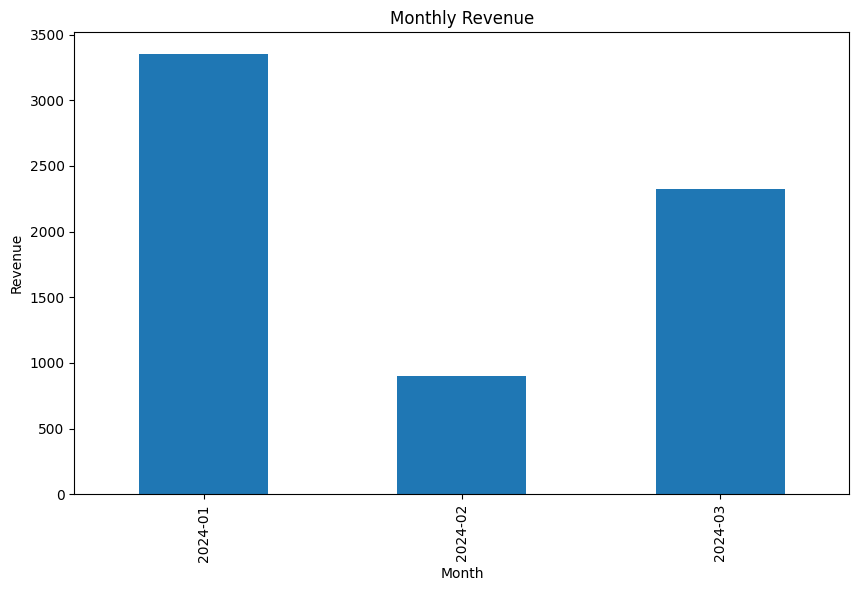

In [39]:
#Plotting Monthly Revenue
monthly_sales.plot(kind='bar', figsize=(10, 6))
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')


2. Time-Based Analysis

-Sales by day / week / month / year

-Peak sales periods

In [43]:
data['Date'] = pd.to_datetime(data['Date'])

In [49]:
data.set_index('Date', inplace=True)
print(data.index)

DatetimeIndex(['2024-01-05', '2024-01-07', '2024-01-10', '2024-02-02',
               '2024-02-10', '2024-02-15', '2024-03-01', '2024-03-05',
               '2024-03-10', '2024-03-15'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [51]:
daily_sales = data['Revenue'].resample('D').sum()   # Daily
monthly_sales = data['Revenue'].resample('M').sum() # Monthly
yearly_sales = data['Revenue'].resample('Y').sum()  # Yearly

C:\Users\Gaura\AppData\Local\Temp\ipykernel_24280\2625645915.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = data['Revenue'].resample('M').sum() # Monthly
C:\Users\Gaura\AppData\Local\Temp\ipykernel_24280\2625645915.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_sales = data['Revenue'].resample('Y').sum()  # Yearly


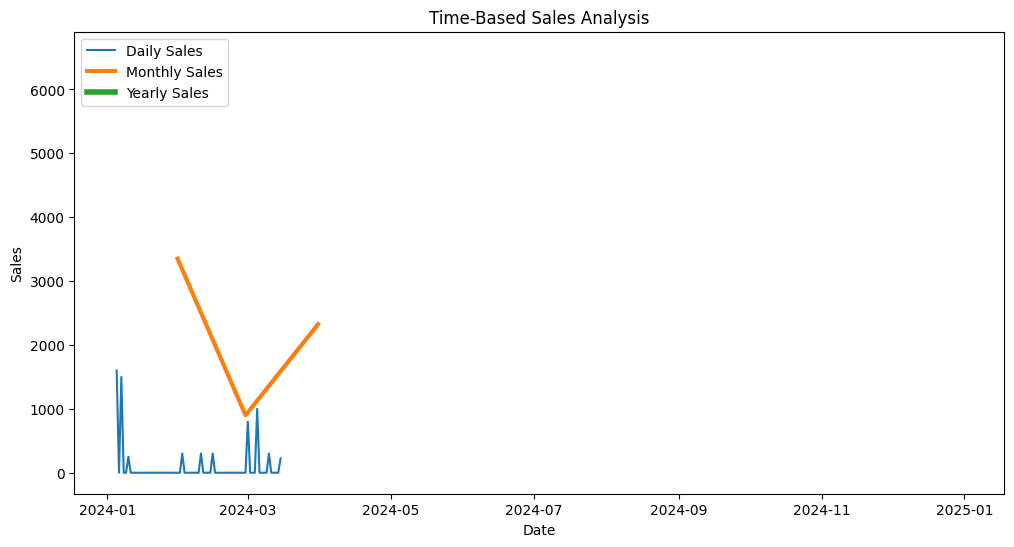

In [52]:
#plotting Daily , Monthly and Yearly Sales
plt.figure(figsize=(12, 6))
plt.plot(daily_sales, label='Daily Sales')
plt.plot(monthly_sales, label='Monthly Sales', linewidth=3)
plt.plot(yearly_sales, label='Yearly Sales', linewidth=4)
plt.title('Time-Based Sales Analysis')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

-Peak Sales Period

In [62]:
# Find the day with maximum sales
peak_day = data.loc[data['Revenue'].idxmax()]
print("Peak sales day:")
print(peak_day)

Peak sales day:
Order_ID           1001
Product          Laptop
Category    Electronics
Quantity              2
Price               800
Revenue            1600
Region        Kathmandu
Month           2024-01
Name: 2024-01-05 00:00:00, dtype: object


3.Product Analysis

-Top-selling products

-Least-selling products

-Product category performance

In [80]:

#Adjust these column names based on actual data
product_col = 'Product'      
sales_col = 'Revenue' 

In [81]:
#Calculating total sales per product
product_sales = data.groupby(product_col)[sales_col].sum()

In [82]:
product_sales = product_sales.sort_values(ascending=False)

In [83]:
print("\nTop 10 Selling Products:")
print(product_sales.head(10))


Top 10 Selling Products:
Product
Phone         2500
Laptop        2400
Headphones     550
Chair          525
Desk           300
Tablets        300
Name: Revenue, dtype: int64


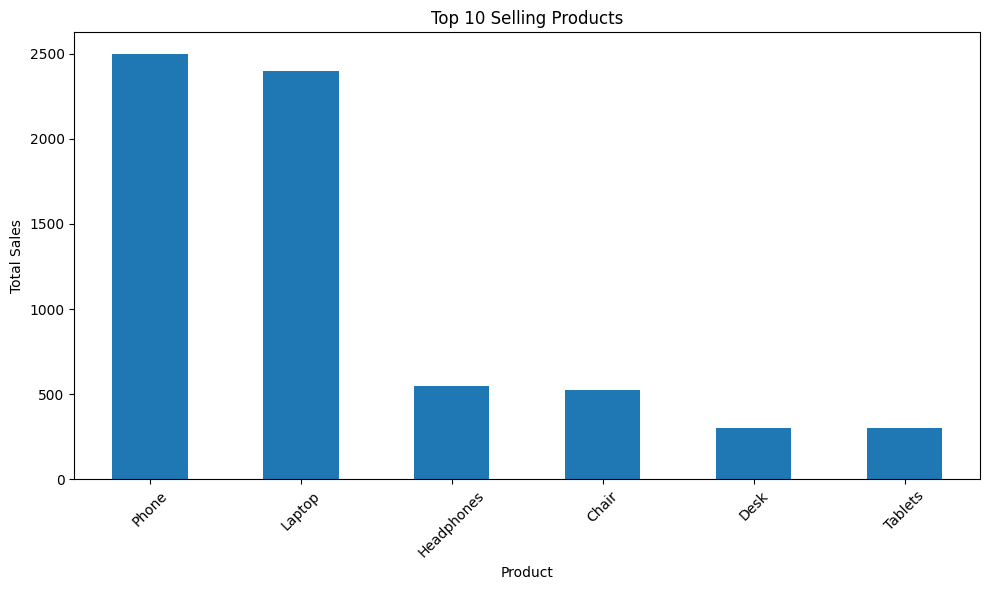

In [84]:
plt.figure(figsize=(10,6))
product_sales.head(10).plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
#Percentage contribution
product_percentage = (product_sales / product_sales.sum()) * 100


In [86]:

print("\nTop 10 Products Contribution (%):")
print(product_percentage.head(10))


Top 10 Products Contribution (%):
Product
Phone         38.022814
Laptop        36.501901
Headphones     8.365019
Chair          7.984791
Desk           4.562738
Tablets        4.562738
Name: Revenue, dtype: float64


-Least Selling Products

In [87]:
#Finding the least selling product
least_product = product_sales.idxmin()
least_value = product_sales.min()


In [88]:
print(f"Least selling product: {least_product}")
print(f"Total sales: {least_value}")

Least selling product: Desk
Total sales: 300


-Product Category Performance

In [89]:
# Using correct column names from the file
category_col = 'Category'   
sales_col = 'Revenue'    

In [90]:
category_sales = data.groupby(category_col)[sales_col].sum().sort_values(ascending=False)

In [91]:
print("Category Performance:\n", category_sales)

Category Performance:
 Category
Electronics    5200
Furniture       825
Accessories     550
Name: Revenue, dtype: int64


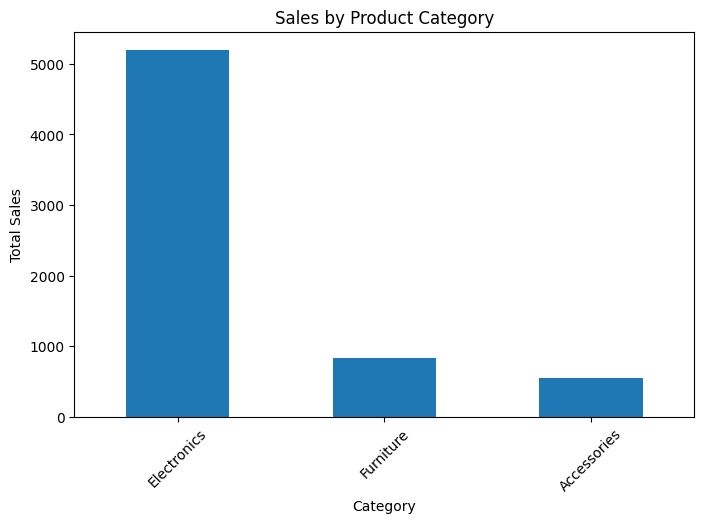

In [92]:
# Plotting sales by category
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

4.Regional / Location Analysis

-Sales by city / region / country

-High-performing vs low-performing areas

In [93]:
region_col = 'Region'
region_sales = data.groupby(region_col)[sales_col].sum().sort_values(ascending=False)

In [94]:
print("\nSales by Region:\n", region_sales)


Sales by Region:
 Region
Kathmandu    2925
Pokhara      1800
Lalitpur     1250
Bhaktapur     600
Name: Revenue, dtype: int64


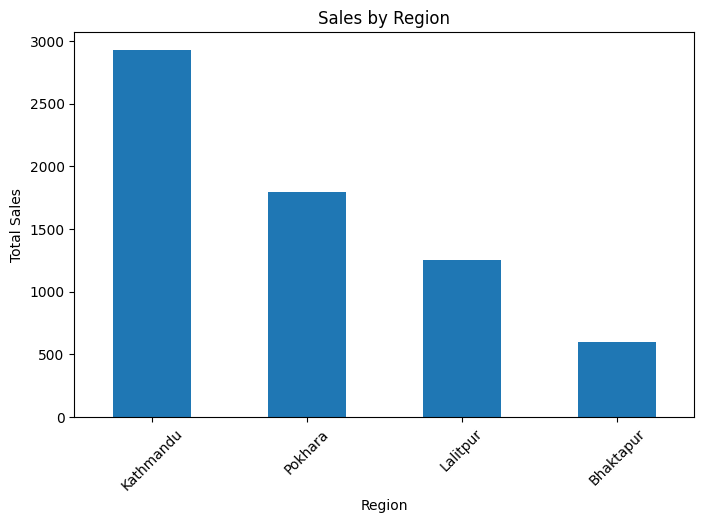

In [95]:
# Plotting on bar chart
plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

-High Performing vs Low Performing Areas

In [96]:
area_col = 'Region'
print(data.columns)

Index(['Order_ID', 'Product', 'Category', 'Quantity', 'Price', 'Revenue',
       'Region', 'Month'],
      dtype='object')


In [98]:
#Total sales by area
area_sales = data.groupby(area_col)[sales_col].sum().sort_values(ascending=False)

print("Sales by Area:\n", area_sales)

Sales by Area:
 Region
Kathmandu    2925
Pokhara      1800
Lalitpur     1250
Bhaktapur     600
Name: Revenue, dtype: int64


In [121]:
# Top 1 high performing areas
top_areas = area_sales.head(1)

In [122]:
# Bottom 1 low performing areas
low_areas = area_sales.tail(1)

In [123]:
# Combining both
combined = pd.concat([top_areas, low_areas])

In [124]:
print("\nTop Performing Areas:\n", top_areas)
print("\nLow Performing Areas:\n", low_areas)


Top Performing Areas:
 Region
Kathmandu    2925
Name: Revenue, dtype: int64

Low Performing Areas:
 Region
Bhaktapur    600
Name: Revenue, dtype: int64


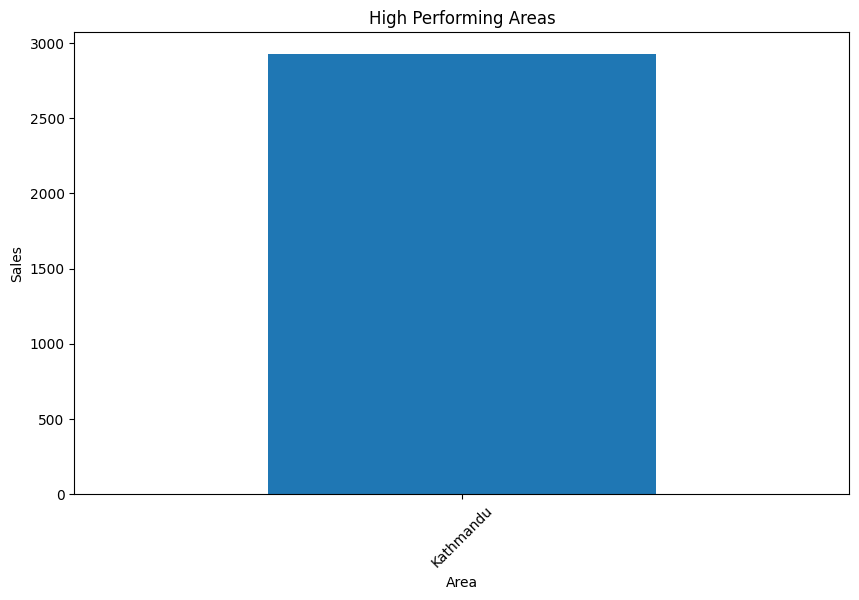

In [128]:
#Plotting top performing areas
plt.figure(figsize=(10,6))
top_areas.plot(kind='bar')
plt.title('High Performing Areas')
plt.xlabel('Area')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()



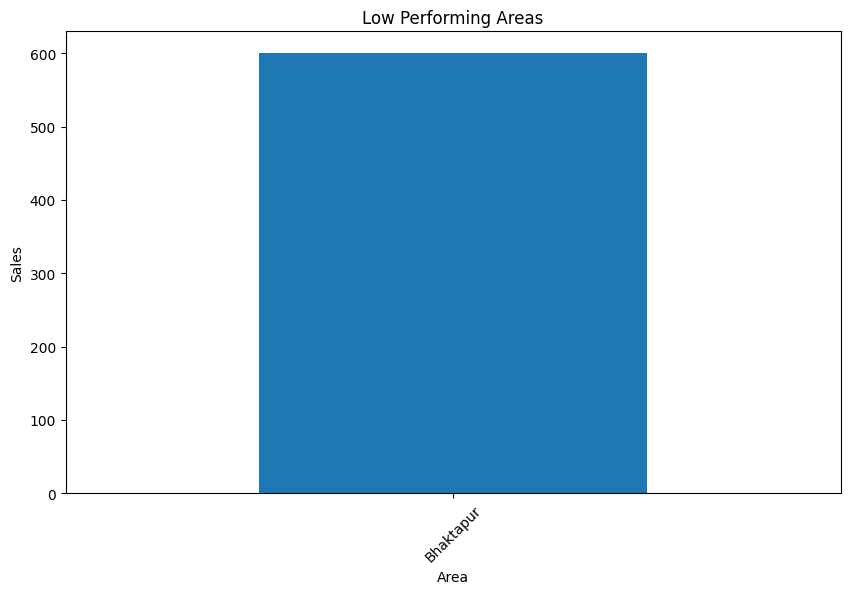

In [129]:
#Plotting low performing areas
plt.figure(figsize=(10,6))
low_areas.plot(kind='bar')
plt.title('Low Performing Areas')
plt.xlabel('Area')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()